# ECE1513: Tutorial 7:
## Function Approximation with Neural Network


Neural networks are powerful function approximators: given examples $((x_i, y_i))$, they can learn a mapping $(f_\theta: \mathcal{X}\to\mathcal{Y})$ by optimizing parameters $(\theta)$.

### Learning goals
- MLPs can approximate complex functions.
- Train a small MLP in PyTorch for regression and classification.

In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1) Warm-up: What does "function approximation" mean?

We observe samples $((x_i, y_i))$ drawn from an unknown process $(y = f^*(x) + \epsilon)$.  
Goal: learn $(f_\theta)$ that minimizes an expected loss, e.g.

$[
\theta^* = \arg\min_\theta \; \mathbb{E}_{(x,y)}[\ell(f_\theta(x), y)]
]$

We'll start with a simple 1D regression problem where you can see the learned function.

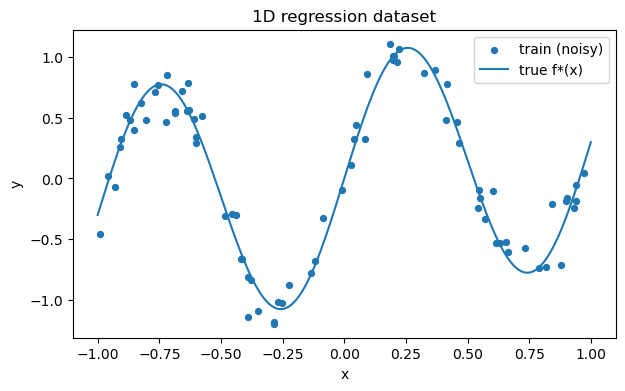

In [21]:
def make_1d_regression(n_train=80, n_val=200, noise_std=0.15):
    x_train = np.random.uniform(-1, 1, size=(n_train, 1))
    x_val   = np.linspace(-1, 1, n_val).reshape(-1, 1)

    def f_star(x):
        return np.sin(2 * math.pi * x) + 0.3 * x

    y_train = f_star(x_train) + noise_std * np.random.randn(*x_train.shape)
    y_val   = f_star(x_val)   # no noise on val curve (for visualization)

    return (x_train, y_train), (x_val, y_val)

(x_train_np, y_train_np), (x_val_np, y_val_np) = make_1d_regression()
x_train = torch.tensor(x_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
x_val   = torch.tensor(x_val_np,   dtype=torch.float32)
y_val   = torch.tensor(y_val_np,   dtype=torch.float32)

plt.figure(figsize=(7,4))
plt.scatter(x_train_np, y_train_np, s=18, label="train (noisy)")
plt.plot(x_val_np, y_val_np, label="true f*(x)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("1D regression dataset")
plt.show()

## 2) Baseline: Linear regression (can it fit?)

A linear model $(y \approx wx + b)$ has limited capacity. It's a useful baseline to diagnose underfitting.

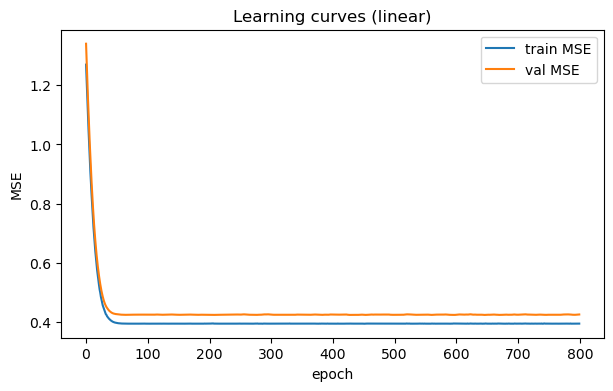

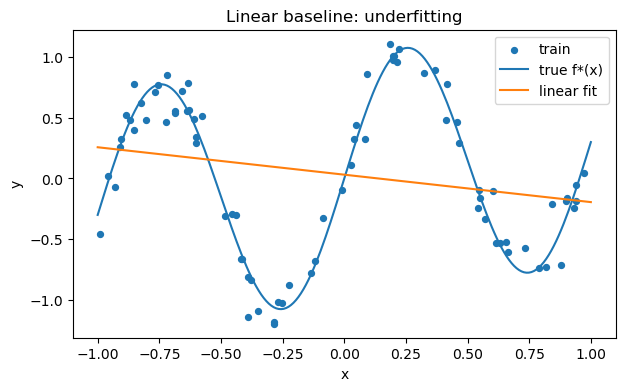

In [22]:
class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(1, 1)
    def forward(self, x):
        return self.lin(x)

def train_regression(model, train_loader, x_val, y_val, 
                     epochs=500, lr=1e-2, verbose=False):
    model = model.to(device)
    x_val = x_val.to(device); y_val = y_val.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []
    for ep in range(1, epochs+1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            val_pred = model(x_val)
            val_loss = loss_fn(val_pred, y_val).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if verbose and (ep % 100 == 0 or ep == 1):
            print(f"epoch {ep:4d} | train MSE {train_loss:.4f} | val MSE {val_loss:.4f}")
    return model, train_losses, val_losses

train_ds = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

lin_model = LinearRegressor()
lin_model, lin_tr, lin_va = train_regression(lin_model, train_loader, x_val, y_val, epochs=800, lr=1e-2)

plt.figure(figsize=(7,4))
plt.plot(lin_tr, label="train MSE")
plt.plot(lin_va, label="val MSE")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("Learning curves (linear)")
plt.show()

# visualize fit
lin_model.eval()
with torch.no_grad():
    yhat = lin_model(x_val.to(device)).cpu().numpy()

plt.figure(figsize=(7,4))
plt.scatter(x_train_np, y_train_np, s=18, label="train")
plt.plot(x_val_np, y_val_np, label="true f*(x)")
plt.plot(x_val_np, yhat, label="linear fit")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Linear baseline: underfitting")
plt.show()

## 3) MLP regression: a neural network as a function approximator

A simple MLP (multi-layer perceptron) composes affine maps with nonlinearities:

$[
x \to W_1 x + b_1 \to \sigma(\cdot) \to W_2 \cdot + b_2 \to \sigma(\cdot) \to \dots
]$

The nonlinearity $(\sigma)$ (e.g., ReLU/Tanh) is what enables rich function classes.

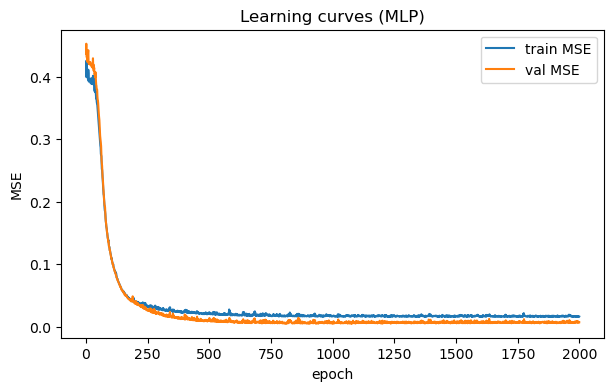

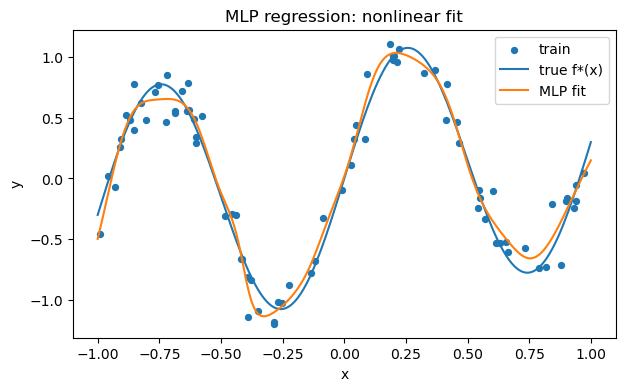

In [23]:
class MLPRegressor(nn.Module):
    def __init__(self, hidden_sizes=(64, 64), activation="tanh"):
        super().__init__()
        acts = {"relu": nn.ReLU, "tanh": nn.Tanh, "gelu": nn.GELU}
        act = acts[activation]

        layers = []
        in_dim = 1
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(act())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

mlp = MLPRegressor(hidden_sizes=(64, 64), activation="tanh")
mlp, mlp_tr, mlp_va = train_regression(mlp, train_loader, x_val, y_val, epochs=2000, lr=2e-3)

plt.figure(figsize=(7,4))
plt.plot(mlp_tr, label="train MSE")
plt.plot(mlp_va, label="val MSE")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("Learning curves (MLP)")
plt.show()

mlp.eval()
with torch.no_grad():
    yhat = mlp(x_val.to(device)).cpu().numpy()

plt.figure(figsize=(7,4))
plt.scatter(x_train_np, y_train_np, s=18, label="train")
plt.plot(x_val_np, y_val_np, label="true f*(x)")
plt.plot(x_val_np, yhat, label="MLP fit")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("MLP regression: nonlinear fit")
plt.show()

### Quick experiment: width/depth and activation

Try changing:
- **Width**: more hidden units can represent more complex functions.
- **Depth**: composing layers can represent certain functions more efficiently.
- **Activation**: ReLU vs Tanh can change smoothness and optimization behavior.

We'll train a few small variants and compare the resulting fits and MSE.

In [24]:
def fit_and_report(hidden_sizes, activation):
    model = MLPRegressor(hidden_sizes=hidden_sizes, activation=activation)
    model, tr, va = train_regression(model, train_loader, x_val, y_val, epochs=1200, lr=2e-3)
    return model, tr[-1], va[-1]

configs = [
    ((16,), "tanh"),
    ((64,), "tanh"),
    ((64,64), "tanh"),
    ((64,64), "relu"),
]

results = []
models = []
for hs, act in configs:
    m, tr_last, va_last = fit_and_report(hs, act)
    results.append((hs, act, tr_last, va_last))
    models.append(m)

for hs, act, tr_last, va_last in results:
    print(f"hidden={','.join(map(str, hs)):12s} act={act:4s} | train MSE {tr_last:.4f} | val MSE {va_last:.4f}")

hidden=16           act=tanh | train MSE 0.1128 | val MSE 0.1024
hidden=64           act=tanh | train MSE 0.0720 | val MSE 0.0637
hidden=64,64        act=tanh | train MSE 0.0164 | val MSE 0.0082
hidden=64,64        act=relu | train MSE 0.0194 | val MSE 0.0062


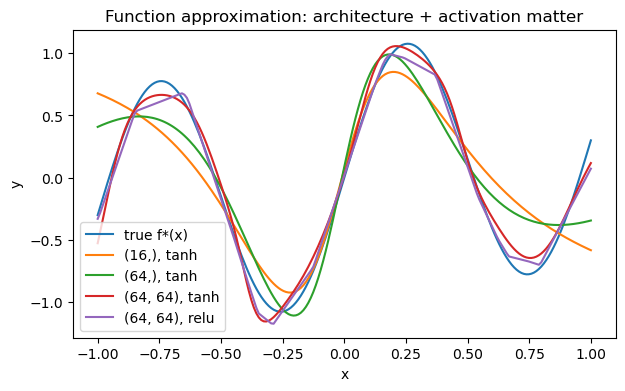

In [25]:
# Plot the learned functions for each configuration
plt.figure(figsize=(7,4))
plt.plot(x_val_np, y_val_np, label="true f*(x)")

for (hs, act, _, _), m in zip(results, models):
    m.eval()
    with torch.no_grad():
        yhat = m(x_val.to(device)).cpu().numpy()
    plt.plot(x_val_np, yhat, label=f"{hs}, {act}")

plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.title("Function approximation: architecture + activation matter")
plt.show()

## 4) 2D example: classification as function approximation

For classification, the network approximates a function that outputs class probabilities.  
For binary classification we often use a *logit* $(z(x))$ and map it to probability with $(\sigma(z)=1/(1+e^{-z}))$.

We'll learn a decision boundary on the classic two moons dataset.

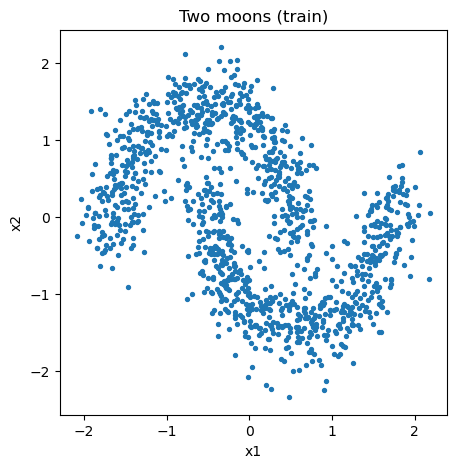

In [26]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1500, noise=0.15, random_state=seed)

# train/val split
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]
split = int(0.8 * len(X))
X_train_np, y_train_np = X[:split], y[:split]
X_val_np,   y_val_np   = X[split:], y[split:]

# standardize inputs (important in practice)
mu = X_train_np.mean(axis=0, keepdims=True)
sd = X_train_np.std(axis=0, keepdims=True) + 1e-8
X_train_np = (X_train_np - mu) / sd
X_val_np   = (X_val_np - mu) / sd

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
X_val   = torch.tensor(X_val_np,   dtype=torch.float32)
y_val   = torch.tensor(y_val_np,   dtype=torch.float32).view(-1, 1)

plt.figure(figsize=(5,5))
plt.scatter(X_train_np[:,0], X_train_np[:,1], s=8)
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Two moons (train)")
plt.show()

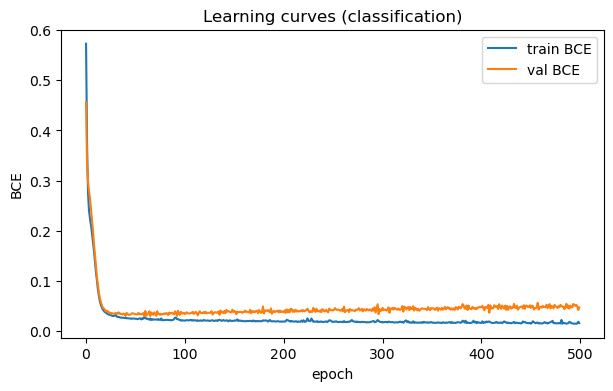

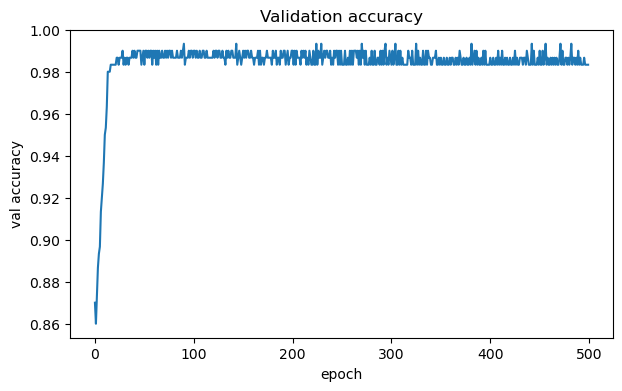

In [27]:
class MLPBinaryClassifier(nn.Module):
    def __init__(self, hidden_sizes=(64,64), activation="relu"):
        super().__init__()
        acts = {"relu": nn.ReLU, "tanh": nn.Tanh, "gelu": nn.GELU}
        act = acts[activation]
        layers = []
        in_dim = 2
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(act())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # logits
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def train_binary_classifier(model, train_loader, X_val, y_val, epochs=400, lr=2e-3, verbose=False):
    model = model.to(device)
    X_val = X_val.to(device); y_val = y_val.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    train_losses, val_losses, val_accs = [], [], []
    for ep in range(1, epochs+1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            logits = model(X_val)
            val_loss = loss_fn(logits, y_val).item()
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            val_acc = (preds.eq(y_val)).float().mean().item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if verbose and (ep % 100 == 0 or ep == 1):
            print(f"epoch {ep:4d} | train BCE {train_loss:.4f} | val BCE {val_loss:.4f} | val acc {val_acc:.3f}")
    return model, train_losses, val_losses, val_accs

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

clf = MLPBinaryClassifier(hidden_sizes=(64,64), activation="relu")
clf, tr, va, acc = train_binary_classifier(clf, train_loader, X_val, y_val, epochs=500, lr=2e-3)

plt.figure(figsize=(7,4))
plt.plot(tr, label="train BCE")
plt.plot(va, label="val BCE")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.legend(); plt.title("Learning curves (classification)")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(acc)
plt.xlabel("epoch"); plt.ylabel("val accuracy"); plt.title("Validation accuracy")
plt.show()

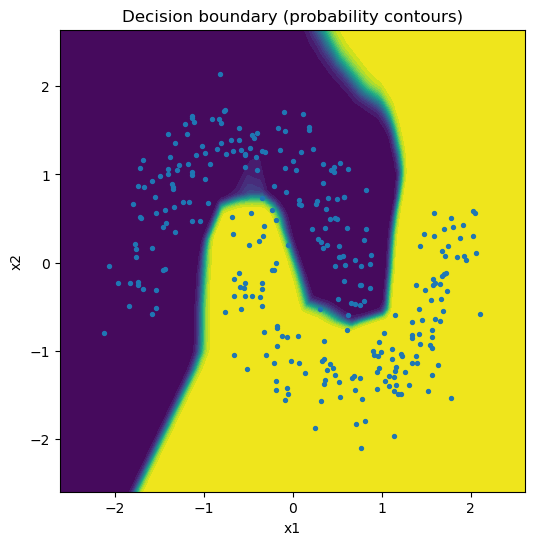

In [28]:
# Visualize decision boundary
def plot_decision_boundary(model, X, y, grid_steps=250):
    model.eval()
    X = np.asarray(X); y = np.asarray(y).reshape(-1)
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

    xs = np.linspace(x_min, x_max, grid_steps)
    ys = np.linspace(y_min, y_max, grid_steps)
    gx, gy = np.meshgrid(xs, ys)
    grid = np.stack([gx.ravel(), gy.ravel()], axis=1)
    grid_t = torch.tensor(grid, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(grid_t).cpu().numpy().reshape(grid_steps, grid_steps)
        probs = 1 / (1 + np.exp(-logits))

    plt.figure(figsize=(6,6))
    plt.contourf(gx, gy, probs, levels=20)
    plt.scatter(X[:,0], X[:,1], s=8)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title("Decision boundary (probability contours)")
    plt.show()

plot_decision_boundary(clf.to(device), X_val_np, y_val_np)